In [ ]:
# Packages install
%pip install ortools==9.15.6755
%pip install ipywidgets==8.1.8
%pip install matplotlib==3.10.8
%pip install plotly==6.6.0

In [441]:
# general imports
import json
import random
import ipywidgets as widgets
import datetime as dt

# Introduction

The Team Formation Problem (TFP) constitutes a well-documented optimization challenge with multiple established solution methodologies. In this work, we propose an approach utilizing constraint programming as the primary solving mechanism. Specifically, we employ Google's OR-Tools library, leveraging its Boolean satisfiability (SAT) solver to formulate and resolve our constraint satisfaction model while optimizing solution quality. The proposed methodology is applied to empirical datasets derived from the National Institute of Standards and Technology (NIST) National Initiative for Cybersecurity Education (NICE) Framework.

# Constraint model

## Allocation variable $x$
$$
\forall t \in T, \forall o \in W, \: \: \: X_{t,o} = \begin{cases}
1 & \text{if the operator $o$ is assigned to $t$},\\
0 & \text{else}
\end{cases}
$$

### Constraints over $x$

#### Team meets human factors requirements
We define that each member of the team must have all the required HF for the task

$$
\forall t \in T, \forall hf \in ReqHF, \: \: \: \sum_{o \in W, hf \in HF_o} X_{t,o} >= 1
$$

More specifically, in our implementation, we tie the number of operators having all the required skills to be >= to the number of operator in the team. We do that to prevent adding unskilled operators to the team. The resulting contrainst is the following.

$$
\forall t \in T, \quad x \geq \sum_{\substack{o \in W \\ X_{t,o} \geq 1}} X_{t,o}
$$

#### Team size constraint
We define the lower bound of the team size to be exactly equals to the upper bound. For that we define two constraints, one for the lower bound, the other for the upper bound.

$$
\forall t \in T, \sum_{o \in W} X_{t,o} >= lb
$$

$$
\forall t \in T, \sum_{o \in W} X_{t,o} <= ub
$$

#### Team cost constraint
We define a hard upper limit on team cost. Team cost must then be <= to the limit

TODO

model.Add(sum(available_workforce[o]["C"] * x[t,o] for o in available_workforce) <= td["C"])

#### Finally, we use an objective function to optimize our result

todo


## How the solver work


In [ ]:
from ortools.sat.python import cp_model

def TFP_solver(terms_weights, tasks, available_workforce, synergies, max_solve_time=20, return_internal_solver_values=False, SAT_and_optimize=True, print_result=False):
    # MODEL
    model = cp_model.CpModel()

    # OPERATORS->TEAMS ASSIGNEMENT VARIABLES
    x = {(t,o): model.NewBoolVar(f"x_{t}_{o}") for t in tasks for o in available_workforce}
    
    # TEAMS SYNERGY VARIABLES
    y = {}

    objective_terms = []

    for t, td in tasks.items():
        
        
        # ================================= #
        #    CAN OP BE ASSIGNED TO TASK     #
        # ================================= #
        
        
        # CONSTRAINT : hf requirements - NIST LIB -> ALL OP MUST COVER ALL HF
            # the sum of all operators for which operator->HF is a subset of task->HF               should be >= to the sum of assignable operators 
        model.Add(sum(x[t,o] for o, od in available_workforce.items() if set(td["S"]).issubset(set(od["S"]))) >= sum(x[t,o] for o in available_workforce))
        
        # CONSTRAINT : team size -> TEAM SIZE SHOULD BE BETWEEN LB AND UB, HERE LB==UB
        model.Add(sum(x[t,o] for o in available_workforce) >= td["TS_LB"])
        model.Add(sum(x[t,o] for o in available_workforce) <= td["TS_UB"])
        
        # CONSTRAINT : team cost -> TEAM COST SHOULD BE UNDER THE COST CAP
        model.Add(sum(available_workforce[o]["C"] * x[t,o] for o in available_workforce) <= td["C"])

        # ==================================== #
        #    TAKE TEAM SYNERGY INTO ACCOUNT    #
        # ==================================== #
        
        for o1 in available_workforce:
            for o2 in available_workforce:
                if o1 != o2:
                    y[t,o1,o2] = model.NewBoolVar(f"y_{t}_{o1}_{o2}")
                    model.Add(y[t,o1,o2] <= x[t,o1])
                    model.Add(y[t,o1,o2] <= x[t,o2])
                    model.Add(y[t,o1,o2] >= x[t,o1] + x[t,o2] - 1)


        # =================================== #
        #        OPTIMIZE THE SOLUTION        #
        # =================================== #
        
        synergy_term = sum(synergies[(o1,o2)]*y[t,o1,o2] for o1 in available_workforce for o2 in available_workforce if o1!=o2)
        
        cost_term    = sum(available_workforce[o]["C"] * x[t,o] for o in available_workforce)
        
        objective_terms.append(terms_weights["synergy"]["w"]*synergy_term + (-1)*terms_weights["cost"]["w"]*cost_term)

    if SAT_and_optimize:
        model.maximize(sum(objective_terms)) 


    # =================================== #
    #                SOLVE                #
    # =================================== #

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = max_solve_time
    status = solver.Solve(model)


    # =================================== #
    #            PRINT RESULTS            #
    # =================================== #

    if print_result: 
        if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
            print("\n===== OPTIMAL TEAM CONSTRUCTION WITH PRECEDENCE =====")
            for t in tasks:
                team = [(o, solver.Value(x[t,o])) for o in available_workforce if solver.Value(x[t,o])==1]
                print(f"Task {t} → Team {team}, cost : {solver.Value(sum(available_workforce[o]["C"] * x[t,o] for o in available_workforce))}")
        else:
            print("No feasible solution found.")
        
    return {t: {
            'team': [o for o in available_workforce if solver.Value(x[t,o])==1],
            'cost': solver.Value(sum(available_workforce[o]["C"] * x[t,o] for o in available_workforce)),
            } 
        for t in tasks}


## NIST's NICE Framework

The NICE Framework (National Initiative for Cybersecurity Education), published by NIST (SP 800-181), is a foundational reference framework that standardizes roles, skills, and tasks in cybersecurity. It provides a common language to help employers, educators, and professionals recruit, train, and develop a qualified workforce.

Its primary goal is to standardize how cybersecurity work is described, categorized, and managed across the federal government and the broader industry.

It provides a dataset composed mainly of **workroles** (grouped into categories) and task and knowledges linked to those workroles.

| Dataset | Description | Download |
|---------|-------------|----------|
| NICE Framework v2.1.0 (XLSX) | version 2.1.0 of the NICE framework in a sheet format. Usefull for browsing | [Download](https://www.nist.gov/document/nice-framework-components-v210) |
| NICE Framework v2.1.0 (JSON) | version 2.1.0 of the NICE framework in a JSON format. Best for compiutationnal use | [Download](https://csrc.nist.gov/csrc/media/Projects/cprt/documents/nice/cprt_SP_800_181_2_1_0_12-11-2025.json) |

For a complete view on the data see [NICE Framework Resource Center](https://www.nist.gov/nice/nice-framework)


In [442]:
# NIST's NICE framework Data Variables

NIST_DATA_TASKS = {}
NIST_DATA_KNOWLEDGES = {}
NIST_DATA_SKILLS = {}
NIST_DATA_WORKROLES = {}
NIST_DATA_TKS_RELATIONSHIPS = []

NIST_DATA_TKS_CROSS_REF = {}

In [443]:
# Read NIST's NICE framework data
def read_nist_data():
    with open('data/v2_1_0_nf_components.json', 'r') as file:
        data = json.load(file)
        for element in data["response"]["elements"]["elements"]:
            match element["element_type"]:
                case "task":
                    NIST_DATA_TASKS[element["element_identifier"]] = {"description": element["text"]}
                case "knowledge":
                    NIST_DATA_KNOWLEDGES[element["element_identifier"]] = {"description": element["text"]}
                case "skill":
                    NIST_DATA_SKILLS[element["element_identifier"]] = {"description": element["text"]}
                case "work_role":
                    NIST_DATA_WORKROLES[element["element_identifier"]] = {"title" :element["title"], "description": element["text"]}
        
        for relation in data["response"]["elements"]["relationships"]:
            NIST_DATA_TKS_RELATIONSHIPS.append({"src": relation["source_element_identifier"], "dst": relation["dest_element_identifier"]})

read_nist_data()

## Determining wich skills and knowledges to assign to each task

On regroupe pour chaques tasks les skills et knowledges qui sont présent dans les autres workroles où il y a ces tasks

In [444]:
# Helper functions and extracting skills and knowledges for each task

def find_elements_of_workrole(workrole_id, element_type):
    element = []
    for relation in NIST_DATA_TKS_RELATIONSHIPS:
        if relation["src"] == workrole_id:
            dest = relation["dst"]
            if dest.upper().startswith(element_type.upper()+"0") or dest.upper().startswith(element_type.upper()+"1") or dest.upper().startswith(element_type.upper()+"2"):
                element.append(dest)
    return element

def find_workroles_of_element(element_id):
    workroles = []
    for relation in NIST_DATA_TKS_RELATIONSHIPS:
        if relation["dst"] == element_id:
            workrole = relation["src"]
            workroles.append(workrole)
    return workroles

def list_cross_referenced_tasks_across_workroles():
    tasks_cross_ref = {}
    for task in NIST_DATA_TASKS:
        workroles = find_workroles_of_element(task)
        tasks_cross_ref[task] = {}
        tasks_cross_ref[task]["workroles"] = workroles
        skills = []
        knowledges = []
        for w in workroles:
            if len(skills) == 0:
                skills = find_elements_of_workrole(w, "S")
            else:
                skills = list(set(skills).intersection(set(find_elements_of_workrole(w, "S"))))
            if len(knowledges) == 0:
                knowledges = find_elements_of_workrole(w, "K")
            else:
                knowledges = list(set(knowledges).intersection(set(find_elements_of_workrole(w, "K"))))
    
        tasks_cross_ref[task]["skills"] = skills
        tasks_cross_ref[task]["knowledges"] = knowledges
    return tasks_cross_ref

NIST_DATA_TKS_CROSS_REF = list_cross_referenced_tasks_across_workroles()


## Manually composing a dataset

## Generate a dataset



In [445]:
# NIST's NICE Framework workroles
print(", ".join([wr for wr in NIST_DATA_WORKROLES]))

OG-WRL-014, OG-WRL-016, OG-WRL-015, OG-WRL-011, OG-WRL-012, OG-WRL-001, OG-WRL-013, OG-WRL-010, OG-WRL-008, OG-WRL-007, OG-WRL-009, OG-WRL-006, OG-WRL-003, OG-WRL-005, IO-WRL-007, IN-WRL-001, IO-WRL-001, IO-WRL-006, OG-WRL-004, OG-WRL-002, PD-WRL-001, IO-WRL-003, IO-WRL-005, IO-WRL-004, IO-WRL-002, IN-WRL-002, PD-WRL-005, PD-WRL-004, PD-WRL-007, PD-WRL-006, PD-WRL-003, DD-WRL-006, DD-WRL-001, DD-WRL-003, DD-WRL-007, DD-WRL-009, DD-WRL-008, PD-WRL-002, DD-WRL-005, DD-WRL-004, DD-WRL-002


In [ ]:
# SET TO TRUE FOR CUSTOM DATA. SET TO FALSE FOR RANDOM DATA
CUSTOM_DATA = False

# ['OG-WRL-014', 'OG-WRL-016', 'OG-WRL-015', 'OG-WRL-011', 'OG-WRL-012', 'OG-WRL-001', 'OG-WRL-013', 'OG-WRL-010', 'OG-WRL-008', 'OG-WRL-007', 'OG-WRL-009', 'OG-WRL-006', 'OG-WRL-003', 'OG-WRL-005', 'IO-WRL-007', 'IN-WRL-001', 'IO-WRL-001', 'IO-WRL-006', 'OG-WRL-004', 'OG-WRL-002', 'PD-WRL-001', 'IO-WRL-003', 'IO-WRL-005', 'IO-WRL-004', 'IO-WRL-002', 'IN-WRL-002', 'PD-WRL-005', 'PD-WRL-004', 'PD-WRL-007', 'PD-WRL-006', 'PD-WRL-003', 'DD-WRL-006', 'DD-WRL-001', 'DD-WRL-003', 'DD-WRL-007', 'DD-WRL-009', 'DD-WRL-008', 'PD-WRL-002', 'DD-WRL-005', 'DD-WRL-004', 'DD-WRL-002']
RANDOM_DATA_P_WORKROLES = {
    'PD-WRL-001': {
        'nb': 20,
        'criteria' : {
            # COST
            'C': {
                'lb': round( ( len(find_elements_of_workrole('PD-WRL-001', "S")) + len(find_elements_of_workrole('PD-WRL-001', "K")) ) / 10 ) - 5,
                'ub': round( ( len(find_elements_of_workrole('PD-WRL-001', "S")) + len(find_elements_of_workrole('PD-WRL-001', "K")) ) / 10 ) + 5,
            }
        }
    },
    'PD-WRL-002': {
        'nb': 20,
        'criteria' : {
            # COST
            'C': {
                'lb': round( ( len(find_elements_of_workrole('PD-WRL-002', "S")) + len(find_elements_of_workrole('PD-WRL-002', "K")) ) / 10 ) - 5,
                'ub': round( ( len(find_elements_of_workrole('PD-WRL-002', "S")) + len(find_elements_of_workrole('PD-WRL-002', "K")) ) / 10 ) + 5,
            }
        }
    },
    'IN-WRL-002': {
        'nb': 20,
        'criteria' : {
            # COST
            'C': {
                'lb': round( ( len(find_elements_of_workrole('IN-WRL-002', "S")) + len(find_elements_of_workrole('IN-WRL-002', "K")) ) / 10 ) - 5,
                'ub': round( ( len(find_elements_of_workrole('IN-WRL-002', "S")) + len(find_elements_of_workrole('IN-WRL-002', "K")) ) / 10 ) + 5,
            }
        }
    },
    'IO-WRL-005': {
        'nb': 20,
        'criteria' : {
            # COST
            'C': {
                'lb': round( ( len(find_elements_of_workrole('IO-WRL-005', "S")) + len(find_elements_of_workrole('IO-WRL-005', "K")) ) / 10 ) - 5,
                'ub': round( ( len(find_elements_of_workrole('IO-WRL-005', "S")) + len(find_elements_of_workrole('IO-WRL-005', "K")) ) / 10 ) + 5,
            }
        }
    },
}

# DATA STRUCTS
AVAILABLE_WORKFORCE = {}
SYNERGY = {}
TASKS = {}
TERMS_WEIGHTS = {}

In [447]:
if CUSTOM_DATA:
    AVAILABLE_WORKFORCE = {}
    AVAILABLE_WORKFORCE = {
        "Alice":   {"workrole" :"PD-WRL-001", "C":16, "S":["S0156","S0483","S0490","S0509","S0543","S0544","S0566","S0567","S0572","S0574","S0578","S0593","S0600","S0614","S0627","S0651","S0667","S0688","S0712","S0722","S0755","S0809","S0838","S0839","S0840","S0846","S0854","S0857","S0859","S0863","S0866","S0867","S0869","S0872","S0874","S0875","S0885","S0892"], "K":["K0018","K0068","K0674","K0675","K0676","K0677","K0678","K0679","K0680","K0681","K0682","K0683","K0684","K0685","K0686","K0689","K0691","K0692","K0694","K0698","K0707","K0710","K0716","K0717","K0718","K0723","K0724","K0725","K0726","K0728","K0729","K0730","K0731","K0732","K0736","K0742","K0743","K0744","K0746","K0747","K0749","K0751","K0752","K0756","K0757","K0758","K0759","K0765","K0766","K0770","K0772","K0773","K0778","K0779","K0781","K0783","K0784","K0785","K0788","K0789","K0790","K0791","K0792","K0793","K0805","K0812","K0813","K0815","K0816","K0829","K0830","K0831","K0832","K0833","K0837","K0840","K0842","K0844","K0845","K0848","K0849","K0851","K0859","K0860","K0861","K0870","K0871","K0877","K0878","K0879","K0880","K0891","K0892","K0915","K0917","K0918","K0919","K0924","K0928","K0937","K0938","K0939","K0940","K0942","K0947","K0948","K0950","K0951","K0955","K0956","K0962","K0963","K0969","K0983","K1014","K1079","K1089","K1108","K1131","K1132","K1144","K1168","K1176","K1181","K1193"],},
        "Bob":     {"workrole" :"PD-WRL-002", "C":14, "S":["S0156","S0378","S0472","S0473","S0474","S0475","S0476","S0491","S0499","S0575","S0576","S0579","S0589","S0599","S0603","S0604","S0605","S0606","S0607","S0608","S0609","S0611","S0612","S0621","S0622","S0623","S0624","S0625","S0651","S0652","S0653","S0671","S0678","S0821","S0854","S0856","S0857","S0860","S0866","S0875","S0882","S0884"], "K":["K0018","K0635","K0636","K0637","K0674","K0675","K0676","K0677","K0678","K0679","K0680","K0681","K0682","K0683","K0684","K0696","K0697","K0701","K0710","K0724","K0725","K0726","K0744","K0751","K0752","K0759","K0760","K0761","K0770","K0778","K0786","K0787","K0791","K0793","K0794","K0795","K0796","K0797","K0800","K0802","K0804","K0806","K0807","K0808","K0809","K0810","K0812","K0817","K0837","K0840","K0842","K0850","K0851","K0852","K0853","K0854","K0855","K0856","K0857","K0858","K0859","K0870","K0871","K0892","K0914","K0915","K0916","K0923","K0939","K0959","K0962","K0963","K0977","K0979","K0980","K0983","K1004","K1014","K1016","K1055","K1069","K1079","K1091","K1092","K1115","K1147","K1151","K1152","K1153","K1154","K1155","K1163","K1175","K1193"],},
        "Charlie": {"workrole" :"IN-WRL-002", "C":12, "S":["S0156","S0378","S0385","S0431","S0472","S0476","S0499","S0579","S0589","S0599","S0605","S0606","S0607","S0608","S0612","S0622","S0623","S0624","S0625","S0651","S0854","S0856","S0857","S0860","S0866","S0884","S0935","S0936","S0937","S0938"], "K":["K0636","K0674","K0675","K0676","K0677","K0678","K0679","K0680","K0681","K0682","K0683","K0684","K0696","K0697","K0701","K0710","K0724","K0725","K0726","K0744","K0751","K0752","K0759","K0760","K0770","K0778","K0786","K0787","K0791","K0793","K0794","K0795","K0796","K0797","K0800","K0802","K0804","K0806","K0808","K0809","K0810","K0812","K0837","K0840","K0842","K0850","K0851","K0852","K0853","K0854","K0855","K0856","K0857","K0858","K0859","K0870","K0871","K0892","K0911","K0914","K0915","K0916","K0923","K0941","K0947","K0962","K0963","K0979","K0983","K1004","K1014","K1016","K1055","K1069","K1079","K1091","K1092","K1115","K1145","K1147","K1151","K1152","K1153","K1154","K1155","K1163","K1175","K1220","K1280","K1281","K1282","K1283","K1284"],},
        "Dan":     {"workrole" :"IN-WRL-002", "C":12, "S":["S0156","S0378","S0385","S0431","S0472","S0476","S0499","S0579","S0589","S0599","S0605","S0606","S0607","S0608","S0612","S0622","S0623","S0624","S0625","S0651","S0854","S0856","S0857","S0860","S0866","S0884","S0935","S0936","S0937","S0938"], "K":["K0636","K0674","K0675","K0676","K0677","K0678","K0679","K0680","K0681","K0682","K0683","K0684","K0696","K0697","K0701","K0710","K0724","K0725","K0726","K0744","K0751","K0752","K0759","K0760","K0770","K0778","K0786","K0787","K0791","K0793","K0794","K0795","K0796","K0797","K0800","K0802","K0804","K0806","K0808","K0809","K0810","K0812","K0837","K0840","K0842","K0850","K0851","K0852","K0853","K0854","K0855","K0856","K0857","K0858","K0859","K0870","K0871","K0892","K0911","K0914","K0915","K0916","K0923","K0941","K0947","K0962","K0963","K0979","K0983","K1004","K1014","K1016","K1055","K1069","K1079","K1091","K1092","K1115","K1145","K1147","K1151","K1152","K1153","K1154","K1155","K1163","K1175","K1220","K1280","K1281","K1282","K1283","K1284"],},
        "Elena":   {"workrole" :"IO-WRL-005", "C":16, "S":["S0045","S0111","S0407","S0408","S0430","S0438","S0448","S0449","S0451","S0472","S0473","S0487","S0488","S0561","S0577","S0582","S0587","S0593","S0606","S0613","S0662","S0663","S0672","S0674","S0675","S0677","S0678","S0687","S0729","S0741","S0762","S0844"], "K":["K0064","K0645","K0674","K0675","K0676","K0677","K0678","K0679","K0680","K0681","K0682","K0683","K0684","K0685","K0686","K0710","K0712","K0713","K0716","K0717","K0728","K0729","K0730","K0731","K0736","K0737","K0740","K0741","K0744","K0746","K0747","K0749","K0751","K0752","K0758","K0759","K0760","K0761","K0765","K0770","K0778","K0779","K0780","K0781","K0791","K0792","K0794","K0805","K0806","K0829","K0830","K0837","K0840","K0842","K0851","K0858","K0859","K0870","K0871","K0877","K0878","K0891","K0915","K0917","K0918","K0919","K0925","K0926","K0928","K0935","K0946","K0947","K0958","K0983","K1014","K1069","K1072","K1188","K1226"],}, #higher cost for demo 
        "Frank":   {"workrole" :"IO-WRL-005", "C":14, "S":["S0045","S0111","S0407","S0408","S0430","S0438","S0448","S0449","S0451","S0472","S0473","S0487","S0488","S0561","S0577","S0582","S0587","S0593","S0606","S0613","S0662","S0663","S0672","S0674","S0675","S0677","S0678","S0687","S0729","S0741","S0762","S0844"], "K":["K0064","K0645","K0674","K0675","K0676","K0677","K0678","K0679","K0680","K0681","K0682","K0683","K0684","K0685","K0686","K0710","K0712","K0713","K0716","K0717","K0728","K0729","K0730","K0731","K0736","K0737","K0740","K0741","K0744","K0746","K0747","K0749","K0751","K0752","K0758","K0759","K0760","K0761","K0765","K0770","K0778","K0779","K0780","K0781","K0791","K0792","K0794","K0805","K0806","K0829","K0830","K0837","K0840","K0842","K0851","K0858","K0859","K0870","K0871","K0877","K0878","K0891","K0915","K0917","K0918","K0919","K0925","K0926","K0928","K0935","K0946","K0947","K0958","K0983","K1014","K1069","K1072","K1188","K1226"],},
    }

    SYNERGY = {
        ('Alice', 'Alice'): 1, 
        ('Alice', 'Bob'): 0.0, 
        ('Alice', 'Charlie'): 0.75, 
        ('Alice', 'Dan'): 0.75, 
        ('Alice', 'Elena'): 0.25, 
        ('Alice', 'Frank'): 0.25, 
        ('Bob', 'Alice'): 0.0, 
        ('Bob', 'Bob'): 1, 
        ('Bob', 'Charlie'): 0.75, 
        ('Bob', 'Dan'): 0.0, 
        ('Bob', 'Elena'): 1.0, 
        ('Bob', 'Frank'): 1.0, 
        ('Charlie', 'Alice'): 0.75, 
        ('Charlie', 'Bob'): 0.75, 
        ('Charlie', 'Charlie'): 1, 
        ('Charlie', 'Dan'): 1.0, 
        ('Charlie', 'Elena'): 0.0, 
        ('Charlie', 'Frank'): 1.0, 
        ('Dan', 'Alice'): 0.75, 
        ('Dan', 'Bob'): 0.0, 
        ('Dan', 'Charlie'): 1.0, 
        ('Dan', 'Dan'): 1, 
        ('Dan', 'Elena'): 0.75, 
        ('Dan', 'Frank'): 0.25, 
        ('Elena', 'Alice'): 0.25, 
        ('Elena', 'Charlie'): 0.0, 
        ('Elena', 'Bob'): 1.0, 
        ('Elena', 'Dan'): 0.75, 
        ('Elena', 'Elena'): 1, 
        ('Elena', 'Frank'): 0.75, 
        ('Frank', 'Bob'): 1.0, 
        ('Frank', 'Alice'): 0.25, 
        ('Frank', 'Charlie'): 1.0, 
        ('Frank', 'Dan'): 0.25, 
        ('Frank', 'Elena'): 0.75, 
        ('Frank', 'Frank'): 1
    }



In [448]:
if not CUSTOM_DATA:
    AVAILABLE_WORKFORCE = {}
    for wr, wr_d in RANDOM_DATA_P_WORKROLES.items():
        for i in range(wr_d['nb']):
            op = {
                "workrole" :wr, 
                "C":random.choices(range(wr_d['criteria']['C']['lb'], wr_d['criteria']['C']['ub']))[0], 
                "S": find_elements_of_workrole(wr, "S"), 
                'K': find_elements_of_workrole(wr, "K"),
            }
            AVAILABLE_WORKFORCE[f'{wr}_{i}'] = op
            
    for o1 in AVAILABLE_WORKFORCE:
        for o2 in AVAILABLE_WORKFORCE:
            s = 1
            if not o1 == o2:
                s = random.choice([0.00, 0.25, 0.75, 1.00])
                S = random.uniform(0,1)
            
            if (o1,o2) not in SYNERGY or (o2,o1) not in SYNERGY:
                SYNERGY[(o1,o2)] = s
                SYNERGY[(o2,o1)] = s
        
        

# Getting results from the model

## Starting a team formation scenario

Now that the model is defined we need to define our tasks as well as their human factor requirements, their team size and finally their maximum cost. We also need to establish the value for beta and gamma and if they influence positively or negatively the results.

In [450]:
TASKS = {
    "t1102": { "S":["S0156","S0605"], "K":["K0796","K1153"], "capable_operators": [], "TS_LB": 2, "TS_UB": 2, "C": 99,},
    "t1384": { "S":["S0574","S0593"], "K":["K0950","K0951"], "capable_operators": [], "TS_LB": 1, "TS_UB": 1, "C": 99,},
    "t1500": { "S":["S0674","S0662"], "K":["K0758","K0760"], "capable_operators": [], "TS_LB": 1, "TS_UB": 1, "C": 99,},
    "t1502": { "S":["S0674","S0662"], "K":["K0758","K0760"], "capable_operators": [], "TS_LB": 1, "TS_UB": 1, "C": 99,},
}

weights_demo_1 = {
    "cost": {"w":5, "operand": "-"},
    "synergy": {"w":10, "operand": "+"},
} 


##### todo
interactive α and β variation using sliders

In [451]:
# slider_cost_weight      = widgets.IntSlider(description='α :',min=0,max=50,value=5,step=1,continuous_update=False,orientation='horizontal')
# check_cost_influence    = widgets.Checkbox(value=True,description='influence negatively',disabled=False,indent=False)
# slider_synergy_weight   = widgets.IntSlider(description='α :',min=0,max=50,value=10,step=1,continuous_update=False,orientation='horizontal',)
# check_synergy_influence = widgets.Checkbox(value=False,description='influence negatively',disabled=False,indent=False)

# children = [
#     widgets.HBox(children=[slider_cost_weight, check_cost_influence]),
#     widgets.HBox(children=[slider_synergy_weight, check_synergy_influence]),
# ]
# tab = widgets.Tab()
# tab.children = children
# tab.titles = ['Team cost', 'Team synergy']
# display(tab)

In [452]:
def plot_results(weights):
   print("\n".join([f'Task {t}: \n\t team: {", ".join(t_d['team'])} \n\t cost: {t_d['cost']}' for t, t_d in TFP_solver(terms_weights=weights).items()]))

plot_results(weights_demo_1)


Task t1102: 
	 team: IN-WRL-002_2, IN-WRL-002_16 
	 cost: 15
Task t1384: 
	 team: PD-WRL-001_6 
	 cost: 11
Task t1500: 
	 team: IO-WRL-005_3 
	 cost: 6
Task t1502: 
	 team: IO-WRL-005_3 
	 cost: 6


# Experimenting the effectiveness of our objective function 

# Varying the values of α and β

the following scatter plots represent the variation of, respectively, total team cost and team synergy for the task T1102.

We start by generating (or loading from already generated data) results for varying values of α and β from 0 to 14. 

We then plot them on a 3d scatter plot, α being on the x axis, β on the y axis and the analized metric on the z axis. 

In [458]:
LOAD_RANDOMLY_GENERATED_DATA = True
TFP_DATA_FILENAME = f"RandomlyGeneratedTfpData-{"2026-03-31 14:08:23.702752"}"
SAVE_RANDOMLY_GENERATED_DATA = False

results = list()

ALPHA_SAMPLES = 15
BETA_SAMPLES  = 15

if LOAD_RANDOMLY_GENERATED_DATA:
     with open(f'data/TFP/{TFP_DATA_FILENAME}.json', "r") as json_file:
        results = json.load(json_file)
else :
    for alpha in range(0,ALPHA_SAMPLES):
        for beta in range(0,BETA_SAMPLES):
            res = TFP_solver({"cost": {"w":beta, "operand": "-"},"synergy": {"w":alpha, "operand": "+"},})
            results.append(res)
        
if SAVE_RANDOMLY_GENERATED_DATA:
    with open(f'data/TFP/RandomlyGeneratedTfpData-{dt.datetime.now()}.json', "w") as json_file:
        json.dump(results, json_file)


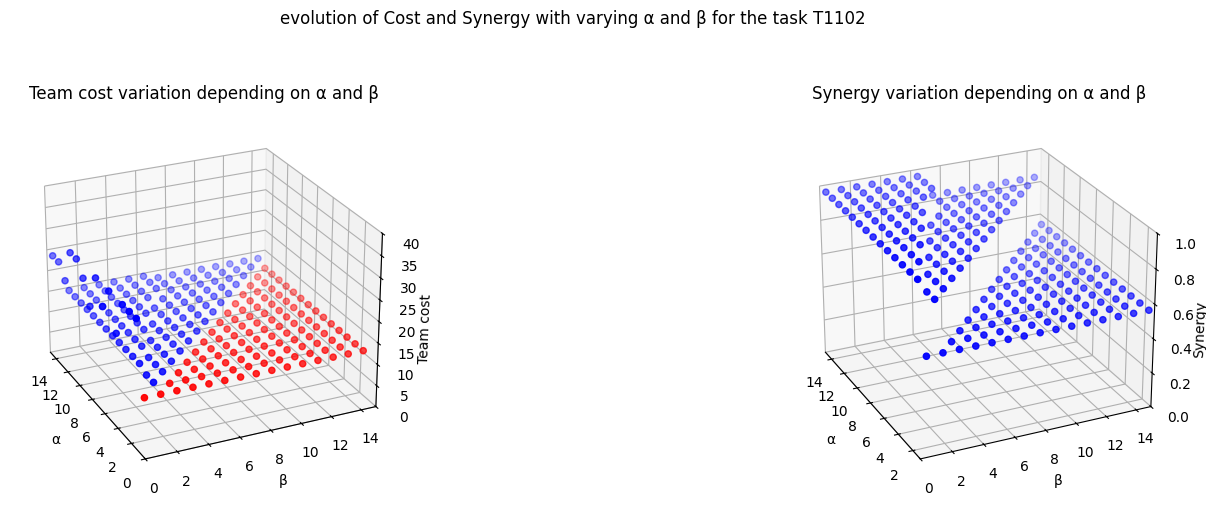

In [474]:
import matplotlib.pyplot as plt
from statistics import mean

alpha =  [ a for a in range(0,ALPHA_SAMPLES) for b in range(0,BETA_SAMPLES)]
beta  =  [ b for a in range(0,ALPHA_SAMPLES) for b in range(0,BETA_SAMPLES)]

fig, (ax_cost, ax_syn) = plt.subplots(1,2, subplot_kw=dict(projection='3d'))

# Make legend, set axes limits and labels
ax_cost.set_title("Team cost variation depending on α and β")
ax_cost.set_xlim(ALPHA_SAMPLES, 0)
ax_cost.set_ylim(0, BETA_SAMPLES)
ax_cost.set_zlim(0, 40)
ax_cost.set_xlabel('α')
ax_cost.set_ylabel('β')
ax_cost.set_zlabel('Team cost')
ax_cost.zaxis.labelpad = -2
ax_cost.zaxis.label_position = 'top'

cost  =  [r['t1102']["cost"] for r in results]
lowest_cost = sorted(cost)[0]

ax_cost.scatter(alpha, beta, zs=cost, c=['red' if c == lowest_cost else 'blue' for c in cost], label='points in (x, z)')

# Customize the view angle so it's easier to see that the scatter points lie on the plane
ax_cost.view_init(elev=25., azim=-25, roll=0)

# Make legend, set axes limits and labels
ax_syn.set_title("Synergy variation depending on α and β")
ax_syn.set_xlim(ALPHA_SAMPLES, 1)
ax_syn.set_ylim(0, BETA_SAMPLES)
ax_syn.set_zlim(0, 1)
ax_syn.set_xlabel('α')
ax_syn.set_ylabel('β')
ax_syn.set_zlabel('Synergy')
ax_syn.zaxis.labelpad = -2
ax_syn.zaxis.label_position = 'top'

synergies  =  [mean([SYNERGY[o1,o2] for o1 in r['t1102']['team'] for o2 in r['t1102']['team']]) for r in results]
highest_synergies = sorted(synergies)

ax_syn.scatter(alpha, beta, zs=synergies, c=['red' if c == highest_synergies else 'blue' for c in synergies], label='points in (x, z)')

# Customize the view angle so it's easier to see that the scatter points lie
# on the plane y=0
ax_syn.view_init(elev=25., azim=-25, roll=0)

fig.suptitle("evolution of Cost and Synergy with varying α and β for the task T1102" )
fig.set_figwidth(15)
fig.set_figheight(6)
plt.subplots_adjust(wspace=1)

plt.show()

In [476]:
# Optionnal, Plotly interactive visalisation

if False :
    import plotly.express as px
    import pandas as pd

    ax = plt.figure(figsize=(5,5)).add_subplot(projection='3d')

    alpha =  [ a for a in range(0,15) for b in range(0,15)]
    beta  =  [ b for a in range(0,15) for b in range(0,15)]
    cost  =  [r['t1102']["cost"] for r in results]
    lowest_cost = sorted(cost)[0]
    colors = ['red' if c == lowest_cost else 'blue' for c in cost]


    df = pd.DataFrame(dict(
        beta  =  [ b for a in range(0,15) for b in range(0,15)],
        alpha =  [ a for a in range(0,15) for b in range(0,15)],
        cost  =  [r['t1102']["cost"] for r in results]
    ))


    fig = px.scatter_3d(df, y='alpha', x='beta', z='cost',
                color=colors)
    fig.show()